# Experiment 3 — Signals in a Geometric Brownian Motion

This notebook implements the three experiments of Chapter 3 of *Design of the Numerical Experiments*: the strength sweep (Experiment 3.1), the signal-quality study including the clean-versus-noisy comparison (Experiment 3.2), and the correlated-assets study (Experiment 3.3).

The object under study is the signal–strength map
$$
w_i(\boldsymbol{s},\beta) \;=\; \frac{e^{\beta s_i}}{\sum_{j=1}^{N} e^{\beta s_j}},
$$
driven by prices simulated from geometric Brownian motion. The design constraint throughout is the **clean-versus-leakage line**: the signal is informative about the future without being the future. The diffusion shock $\phi_i$, which realises the price, never enters the signal.

## Model and simulation design

**One-step return.** Each stock follows a one-step geometric Brownian motion,
$$R_i=\exp[(\mu_i-\tfrac12\sigma_i^2)\Delta t+\sigma_i\sqrt{\Delta t}\,\phi_i]-1,$$
with the drift-tracking signal $s_i=\mu_i+\varepsilon_i$ and $\varepsilon_i\perp(\mu_i,\phi_i)$. Thus a clean signal reveals expected drift, not the realised diffusion shock.

**Common performance measure.** Every portfolio in Chapters 3 and 4 is scored by the mean--variance certainty equivalent
$$
\mathrm{CE}_{MV}(P)=\mathbb E[P]-\frac{\gamma}{2}\operatorname{Var}(P),
$$
reported in basis points relative to equal weight. The same coefficient $\gamma=5$ is used throughout. This common evaluator is required for a valid comparison with the shortable combination map: under lognormal gross returns, a genuine negative holding makes the population CARA exponential moment infinite. Mean--variance CE is finite for the portfolios studied here and is estimated with the population variance convention (`ddof=0`).

**Common random numbers.** The same draws of $(\mu,\varepsilon_0,\phi)$ are reused across the strength grid and noise ladder. Differences are paired draw by draw; six-block paired Monte-Carlo standard errors are reported for headline gains.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------- parameters ----------------
N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # mean--variance risk coefficient
n_sims   = 30_000    # Monte-Carlo replications

beta_grid = np.linspace(0.0, 120.0, 121)   # step 1; peaks sit around 1/sigma_mu = 20

# ---------------- common random numbers ----------------
# One set of draws shared by every beta and every sigma_eps.
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # diffusion shocks (never in the signal)

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0


In [2]:
def softmax_weights(s, beta):
    # w_i = exp(beta s_i) / sum_j exp(beta s_j), computed stably row by row
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_mv(port):
    """Mean--variance certainty equivalent, with population (ddof=0) variance."""
    return port.mean() - 0.5 * gamma * port.var(ddof=0)

def mv_curve(sigma_eps, beta_grid=beta_grid):
    s = mu + sigma_eps * eps0
    CE = np.empty(len(beta_grid))
    for k, b in enumerate(beta_grid):
        w = softmax_weights(s, b)
        CE[k] = ce_mv((w * R).sum(axis=1))
    return CE

def mv_curve_R(R_mat, sigma_eps, beta_grid=beta_grid):
    s = mu + sigma_eps * eps0
    return np.array([ce_mv((softmax_weights(s, b) * R_mat).sum(axis=1)) for b in beta_grid])

def beta_star(beta_grid, CE):
    k = int(np.argmax(CE))
    return beta_grid[k], CE[k], k

def paired_block_ce(p_a, p_b, n_blocks=6):
    """Paired block estimate and Monte-Carlo SE of CE_MV(a)-CE_MV(b)."""
    vals = []
    for ix in np.array_split(np.arange(len(p_a)), n_blocks):
        vals.append(1e4 * (ce_mv(p_a[ix]) - ce_mv(p_b[ix])))
    vals = np.asarray(vals)
    return vals.mean(), vals.std(ddof=1) / np.sqrt(len(vals))


## Experiment 3.1 — Strength sweep

Sweep $\beta$ upward from equal weight and ask whether $\Delta\mathrm{CE}_{MV}(\beta)$ is monotone. A stronger signal tilt raises expected return but also increases portfolio variance by concentrating weight. An interior maximiser therefore records the point at which the marginal mean gain is overtaken by the marginal variance cost; it is not created mechanically by a grid boundary.


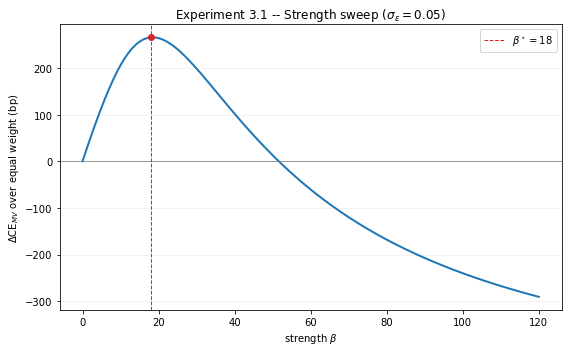

beta* = 18.0
CE_MV gain at beta*: 266.1 bp over equal weight
paired six-block MC SE of the gain: 5.6 bp


In [3]:
sigma_eps_base = 0.05

CE_b = mv_curve(sigma_eps_base)
bstar, ce_at_bstar, k = beta_star(beta_grid, CE_b)
dCE_b = CE_b - CE_b[0]

s_base = mu + sigma_eps_base * eps0
p_0 = (softmax_weights(s_base, 0.0) * R).sum(axis=1)
p_star = (softmax_weights(s_base, bstar) * R).sum(axis=1)
block_mean, se_dCE = paired_block_ce(p_star, p_0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(beta_grid, 1e4 * dCE_b, lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(bstar, color='tab:red', ls='--', lw=1, label=fr'$\beta^\star = {bstar:.0f}$')
ax.scatter([bstar], [1e4 * dCE_b[k]], color='tab:red', zorder=5)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE$_{MV}$ over equal weight (bp)')
ax.set_title(fr'Experiment 3.1 -- Strength sweep ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.grid(axis='y', alpha=0.2); ax.legend()
plt.tight_layout(); plt.show()

print(f"beta* = {bstar:.1f}")
print(f"CE_MV gain at beta*: {1e4*dCE_b[k]:.1f} bp over equal weight")
print(f"paired six-block MC SE of the gain: {se_dCE:.1f} bp")


**Reading.** The maximiser is interior: $\beta^\star=18$ and the peak gain is $266.1$ bp over equal weight, with a paired six-block Monte-Carlo standard error of $5.6$ bp. That standard error concerns the gain relative to equal weight, not the location of the maximiser. The objective is locally shallow: $\beta=19$ differs from $\beta=18$ by only $-0.09$ bp (paired block SE $0.41$ bp), and the six blockwise maximisers range from $17$ to $19$. The experiment therefore identifies a moderate interior region more sharply than one unique value of $\beta$. Performance is nevertheless non-monotone in strength. At $\beta=54$ the mean return is higher than at the optimum, but volatility has almost doubled and $\Delta\mathrm{CE}_{MV}$ has fallen to $-18.1$ bp. Aggressive tilting therefore backfires even though the signal remains informative.


### The optimum in P&L terms

The paired return difference compares the tilted portfolio and equal weight in the same simulated state. At $\beta^\star=18$, the tilt beats equal weight in $71.5\%$ of draws and raises the mean return by $416$ bp, but its 5% paired-return quantile is $-640$ bp. These P&L summaries explain the mean--variance trade-off; they do not replace the common CE criterion.


  beta     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
     0    5.28%    4.91%    14.0%   -2.63%           --       0.0
    18    9.44%    9.17%    13.5%   -3.94%        71.5%     266.1
    54   12.01%   17.33%    24.0%  -13.03%        64.4%     -18.1


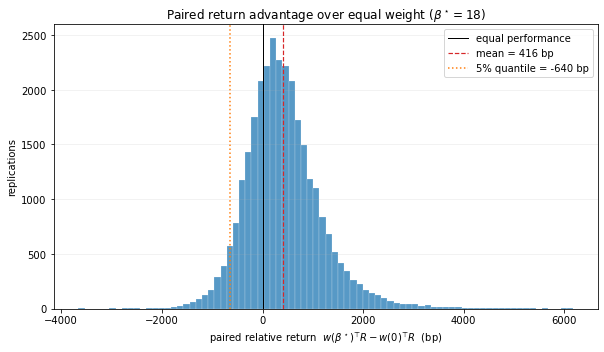

P(tilt beats 1/N) = 71.5%
mean relative return = 416 bp,  5% quantile = -640 bp


In [4]:
# ---- P&L view of the CE optimum (paired against equal weight) ----
betas_show = [0.0, bstar, 3 * bstar]

ports, rows = {}, []
for b in betas_show:
    w = softmax_weights(s_base, b)
    p = (w * R).sum(axis=1)
    ports[b] = p
    ce = ce_mv(p)
    rows.append((b, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if b > 0 else np.nan,
                 1e4 * (ce - CE_b[0])))

print(f"{'beta':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>8} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for b, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{b:>6.0f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>8.2%} {pb_s} {dce:>9.1f}")

# Paired relative return at beta*: both portfolios face the same simulated state.
d = ports[bstar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\beta^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\beta^\star = {bstar:.0f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(tilt beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

## Experiment 3.2 — Signal quality

Vary $\sigma_\varepsilon$ and re-optimise $\beta$. The Gaussian posterior mean is
$$\mathbb E[\mu_i\mid s_i]=\bar\mu+\kappa(s_i-\bar\mu),\qquad
\kappa=\frac{\sigma_\mu^2}{\sigma_\mu^2+\sigma_\varepsilon^2}.$$
Because softmax is shift-invariant, acting on this posterior with strength $\beta$ traces the same portfolios as acting on the raw signal with effective strength $\beta\kappa$. The curve $\beta^\star_{clean}\kappa$ is therefore a reliability benchmark, not an identity for the welfare optimum: risk, return scale and the evaluator also affect $\beta^\star$.


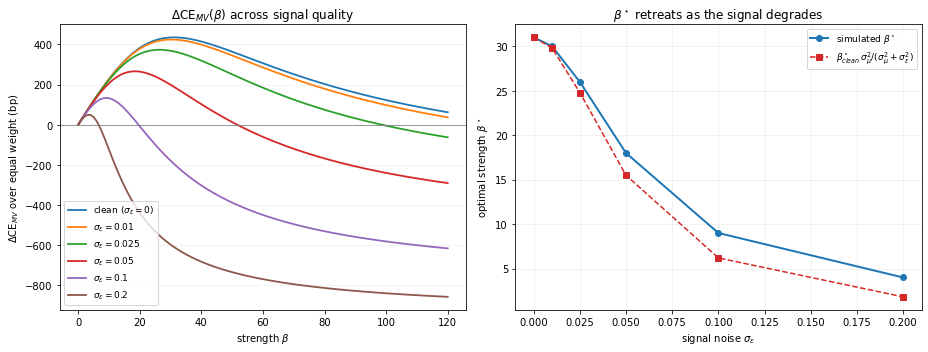

 sigma_eps    beta*  shrinkage pred.  peak dCE_MV (bp)
       0.0       31               31             435.3
      0.01       30               30             424.4
     0.025       26               25             373.6
      0.05       18               16             266.1
       0.1        9                6             133.6
       0.2        4                2              49.0


In [5]:
sigma_eps_levels = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
results = {se: mv_curve(se) for se in sigma_eps_levels}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for se in sigma_eps_levels:
    CE = results[se]
    label = 'clean ($\\sigma_\\varepsilon=0$)' if se == 0 else fr'$\sigma_\varepsilon={se}$'
    ax.plot(beta_grid, 1e4 * (CE - CE[0]), lw=1.8, label=label)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$'); ax.set_ylabel(r'$\Delta$CE$_{MV}$ over equal weight (bp)')
ax.set_title(r'$\Delta$CE$_{MV}(\beta)$ across signal quality')
ax.grid(axis='y', alpha=0.2); ax.legend(fontsize=9)

bstars = np.array([beta_star(beta_grid, results[se])[0] for se in sigma_eps_levels])
kappa  = sigma_mu**2 / (sigma_mu**2 + np.array(sigma_eps_levels)**2)
pred   = bstars[0] * kappa
ax = axes[1]
ax.plot(sigma_eps_levels, bstars, 'o-', lw=2, label=r'simulated $\beta^\star$')
ax.plot(sigma_eps_levels, pred, 's--', lw=1.5, color='tab:red',
        label=r'$\beta^\star_{clean}\,\sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$'); ax.set_ylabel(r'optimal strength $\beta^\star$')
ax.set_title(r'$\beta^\star$ retreats as the signal degrades')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} {'beta*':>8} {'shrinkage pred.':>16} {'peak dCE_MV (bp)':>17}")
for se, bs, pr in zip(sigma_eps_levels, bstars, pred):
    CE = results[se]
    print(f"{se:>10} {bs:>8.0f} {pr:>16.0f} {1e4*(CE.max()-CE[0]):>17.1f}")


**Reading.** Both optimal strength and achievable value retreat with signal quality. From the clean to the noisiest signal, $\beta^\star$ falls $31\to30\to26\to18\to9\to4$, while the peak gain falls $435.3\to424.4\to373.6\to266.1\to133.6\to49.0$ bp. The reliability curve is close at low noise and understates the surviving strength at high noise. The defensible conclusion is qualitative: a more reliable signal supports a stronger tilt; $\beta$ should not be identified numerically with posterior precision.


### Clean versus noisy: two gaps

Comparing the clean signal with $\sigma_\varepsilon=0.10$ separates the value loss from the strength response. The clean optimum is $435.3$ bp at $\beta^\star=31$; the noisy optimum is $133.6$ bp at $\beta^\star=9$. Thus noise costs $301.7$ bp at the respective optima and pulls optimal strength back by $22$. Perfect drift information still does not reveal the realised return, because the diffusion shock remains firewalled.


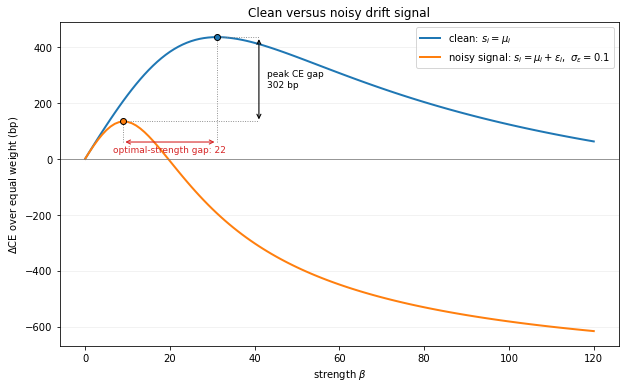

clean : beta* = 31, peak gain = 435.3 bp
noisy signal: beta* = 9, peak gain = 133.6 bp
peak CE gap (cost of noise at the two optima) = 301.7 bp
optimal-strength gap = 22


In [6]:
se_noisy = 0.10
CE_or = results[0.0]
CE_no = results[se_noisy]
d_or, d_no = 1e4 * (CE_or - CE_or[0]), 1e4 * (CE_no - CE_no[0])

b_or, _, k_or = beta_star(beta_grid, CE_or)
b_no, _, k_no = beta_star(beta_grid, CE_no)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
clean_color, noisy_color = 'tab:blue', 'tab:orange'
ax.plot(beta_grid, d_or, lw=2, color=clean_color, label=r'clean: $s_i=\mu_i$')
ax.plot(beta_grid, d_no, lw=2, color=noisy_color,
        label=fr'noisy signal: $s_i=\mu_i+\varepsilon_i,\ \sigma_\varepsilon={se_noisy}$')
ax.axhline(0, color='grey', lw=0.8)
ax.scatter(b_or, d_or[k_or], color=clean_color, edgecolor='black', zorder=5)
ax.scatter(b_no, d_no[k_no], color=noisy_color, edgecolor='black', zorder=5)

# Vertical bracket compares the two maximum CE gains. Horizontal guides make
# clear that these values occur at different strengths.
x_gap = b_or + 10
ax.hlines(d_or[k_or], b_or, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.hlines(d_no[k_no], b_no, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(x_gap, d_no[k_no]), xytext=(x_gap, d_or[k_or]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.1))
ax.text(x_gap + 2, 0.5 * (d_no[k_no] + d_or[k_or]),
        f'peak CE gap\n{d_or[k_or] - d_no[k_no]:.0f} bp', va='center', fontsize=9)

# Horizontal bracket compares the locations of the two optima.
y_gap = 0.45 * d_no[k_no]
ax.vlines([b_no, b_or], y_gap, [d_no[k_no], d_or[k_or]],
          colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(b_or, y_gap), xytext=(b_no, y_gap),
            arrowprops=dict(arrowstyle='<->', color='tab:red', lw=1.1))
ax.text(0.5 * (b_or + b_no), y_gap - 35,
        fr'optimal-strength gap: {b_or - b_no:.0f}',
        fontsize=9, ha='center', color='tab:red')
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Clean versus noisy drift signal')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"clean : beta* = {b_or:.0f}, peak gain = {d_or[k_or]:.1f} bp")
print(f"noisy signal: beta* = {b_no:.0f}, peak gain = {d_no[k_no]:.1f} bp")
print(f"peak CE gap (cost of noise at the two optima) = {d_or[k_or]-d_no[k_no]:.1f} bp")
print(f"optimal-strength gap = {b_or-b_no:.0f}")


## Experiment 3.3 — Correlated assets

The diffusion shocks are first given equicorrelation,
$$\phi_i=\sqrt\rho Z_0+\sqrt{1-\rho}Z_i,$$
and then a seed-fixed three-factor structure. Signals and all non-correlation parameters are unchanged.

For the Gaussian diffusion component of a fully invested portfolio,
$$\operatorname{Var}(\sigma w^\top\phi)=\sigma^2[\rho+(1-\rho)\lVert w\rVert^2].$$
The common component is fixed by $\mathbf1^\top w=1$, while the concentration-sensitive component is discounted by $1-\rho$. This gives a structural prediction that stronger relative tilts become cheaper as $\rho$ rises. Because the simulation scores lognormal simple returns, the formula is the local-risk mechanism rather than an exact decomposition of the final CE.


factor-model correlations: mean 0.16, min -0.21, max 0.57



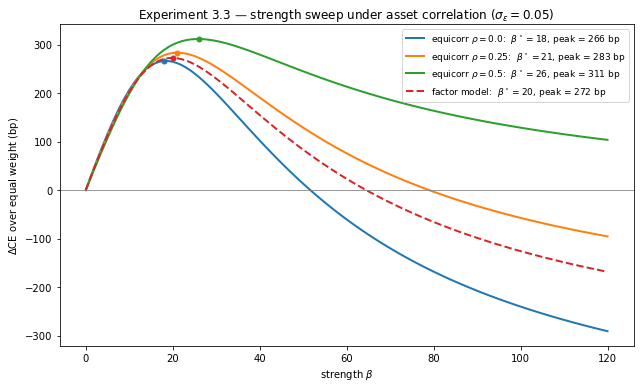

              case  avg corr   beta*  peak dCE (bp)  CE(0) level
      equicorr rho=0.0      0.00      18          266.1       0.0468
     equicorr rho=0.25      0.25      21          283.2       0.0202
      equicorr rho=0.5      0.50      26          311.4      -0.0067
          factor model      0.16      20          272.5       0.0293


In [7]:
# ---- Experiment 3.3: correlated diffusion shocks ----
# (a) equicorrelation: phi_i = sqrt(rho) Z0 + sqrt(1-rho) Z_i
rho_levels = [0.0, 0.25, 0.5]

rng_corr = np.random.default_rng(4242)
z0 = rng_corr.standard_normal((n_sims, 1))          # common factor, shared across all rho

def mv_curve_R_local(R_mat, sigma_eps):
    return mv_curve_R(R_mat, sigma_eps)

res_corr = {}
for rho in rho_levels:
    phi_rho = np.sqrt(rho) * z0 + np.sqrt(1.0 - rho) * phi
    R_rho = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_rho) - 1.0
    res_corr[fr'equicorr $\rho={rho}$'] = mv_curve_R_local(R_rho, sigma_eps_base)

# (b) random factor model: loadings drawn once (seed-fixed), heterogeneous correlations
k_fac = 3
rng_fac = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0]  = 0.45 + 0.15 * rng_fac.standard_normal(N)        # market factor: positive, heterogeneous
B[:, 1:] = 0.30 * rng_fac.standard_normal((N, k_fac - 1))  # style factors: mixed signs
norms = np.sqrt((B**2).sum(axis=1))
too_big = norms > 0.95
B[too_big] *= (0.95 / norms[too_big])[:, None]              # keep idiosyncratic variance positive
idio = np.sqrt(1.0 - (B**2).sum(axis=1))

C_fac = B @ B.T
np.fill_diagonal(C_fac, 1.0)
off = C_fac[~np.eye(N, dtype=bool)]
print(f"factor-model correlations: mean {off.mean():.2f}, min {off.min():.2f}, max {off.max():.2f}\n")

F = rng_fac.standard_normal((n_sims, k_fac))                # factor shocks
phi_fac = F @ B.T + phi * idio                              # baseline idio draws reused (paired)
R_fac = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_fac) - 1.0
res_corr['factor model'] = mv_curve_R_local(R_fac, sigma_eps_base)

# ---- results ----
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, CE in res_corr.items():
    dCE = 1e4 * (CE - CE[0])
    bs, _, kk = beta_star(beta_grid, CE)
    ls = '--' if name == 'factor model' else '-'
    ax.plot(beta_grid, dCE, lw=2, ls=ls, label=fr'{name}:  $\beta^\star={bs:.0f}$, peak = {dCE[kk]:.0f} bp')
    ax.scatter([bs], [dCE[kk]], zorder=5, s=25)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment 3.3 — strength sweep under asset correlation ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'case':>18} {'avg corr':>9} {'beta*':>7} {'peak dCE (bp)':>14} {'CE(0) level':>12}")
for name, CE in res_corr.items():
    bs, _, kk = beta_star(beta_grid, CE)
    avg = {'equicorr $\\rho=0.0$': 0.0, 'equicorr $\\rho=0.25$': 0.25,
           'equicorr $\\rho=0.5$': 0.5}.get(name, off.mean())
    clean_name = name.replace('$', '').replace('\\rho', 'rho')
    print(f"{clean_name:>22} {avg:>9.2f} {bs:>7.0f} {1e4*(CE[kk]-CE[0]):>14.1f} {CE[0]:>12.4f}")

**Reading.** Under the mean--variance evaluator, $\beta^\star$ rises $18\to21\to26$ as $\rho$ moves from $0$ to $0.5$, and the peak gain rises $266.1\to283.2\to311.4$ bp. The equal-weight CE level falls from $4.68\%$ to $-0.67\%$. The result is consistent with the variance mechanism: correlation raises risk shared by every fully invested portfolio while reducing the incremental concentration penalty relative to equal weight.

The factor draw has mean pairwise correlation $0.16$ and produces $\beta^\star=20$ with a $272.5$ bp peak. This is one seed-fixed loading structure, so it supports robustness within this calibration rather than a universal mapping from average correlation to performance.


## Methodological notes

**Common estimator.** All reported performance uses $\mathrm{CE}_{MV}=\mathbb E[P]-(\gamma/2)\operatorname{Var}(P)$. The former CARA outputs are not retained: although CARA is finite for the long-only softmax portfolios, it is not finite for the shortable comparison family under lognormal returns, so mixing the two evaluators would invalidate the head-to-head.

**Scale and uncertainty.** The signal is measured in annual drift units, so $\beta$ is naturally of order $1/\sigma_\mu$. Common random numbers smooth comparisons but do not remove sampling uncertainty; the baseline gain carries a paired six-block Monte-Carlo SE, and $\beta^\star$ also has grid-resolution uncertainty.

**Interpretive scope.** The equicorrelation variance formula is exact for the Gaussian diffusion component and motivates the result, but the reported CE is computed from simulated lognormal simple returns. Numerical levels are parameter- and seed-specific; the stable findings are the interior optimum, retreat with noise, and the direction of the equicorrelation response in the tested design.
